# 🏢 Employee Dataset — Full ML Pipeline

**Dataset:** Employee HR Data (5040 rows, 20 columns)

**Target Variable:** `left_company` → 0 = Stayed, 1 = Left

---

## 🗺️ What We Will Do — Step By Step

| Step | Task |
|------|------|
| 1 | Load Dataset & Basic Info |
| 2 | EDA — Exploratory Data Analysis |
| 3 | Data Cleaning |
| 4 | Feature Engineering |
| 5 | Encoding Categorical Columns |
| 6 | Final Check — Ready For ML |

---

## ⚠️ Dataset Messiness (Injected On Purpose)

- `salary` column has `PKR` prefix in some rows (e.g. `PKR60000`)
- `joining_year` has `Year-` prefix in some rows (e.g. `Year-2018`)
- `gender` has inconsistent strings (`male`, `M`, `MALE`, `m`)
- `city` has inconsistent strings (`karachi`, `LAHORE`, `islamabad `)
- Age outliers (0, -5, 150)
- Salary outliers (-999, 0, 9999999)
- ~8% missing values in: `job_title`, `bonus_percent`, `training_hours`, `satisfaction_score`, `last_promotion_year`
- 40 duplicate rows

---

## 📦 Step 0 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

import warnings
warnings.filterwarnings('ignore')

---
## 📂 Step 1 — Load Dataset & Basic Info

In [3]:
df = pd.read_csv("employee_messy.csv")
df.head()

,employee_id,name,age,gender,city,education,department,job_title,experience_years,salary,bonus_percent,working_hours_per_week,performance_rating,remote_work,joining_year,last_promotion_year,projects_completed,training_hours,satisfaction_score,left_company
0,EMP4351,Edward Garcia,54,Male,Karachi,Masters,HR,Doctor,18,106419,5.0,38,Poor,No,2011,NaN,49,40.0,5.9,0
1,EMP3306,Diana Bradford,25,Male,Multan,Bachelors,Marketing,Teacher,20,51889,0.0,44,Average,Yes,2011,2013.0,22,193.0,2.9,0
2,EMP1737,Zachary Poole,51,Female,Quetta,Bachelors,Finance,Teacher,10,56508,25.0,39,Excellent,Yes,2015,2023.0,41,153.0,9.8,0
3,EMP3051,Alyssa Thompson,46,Male,Multan,Secondary,HR,NaN,27,27058,5.0,51,Good,No,2020,NaN,17,NaN,3.9,1
4,EMP3312,Stephanie Gibson,37,m,Quetta,Masters,Sales,NaN,10,82849,10.0,30,Good,No,2006,2023.0,29,160.0,7.7,0


In [4]:
df.shape

(5040, 20)

In [5]:
df.columns

Index(['employee_id', 'name', 'age', 'gender', 'city', 'education',
       'department', 'job_title', 'experience_years', 'salary',
       'bonus_percent', 'working_hours_per_week', 'performance_rating',
       'remote_work', 'joining_year', 'last_promotion_year',
       'projects_completed', 'training_hours', 'satisfaction_score',
       'left_company'],
      dtype='str')

In [6]:
# See dtypes and null counts
# Notice: salary and joining_year are 'object' even though they should be numbers
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5040 entries, 0 to 5039
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             5040 non-null   str    
 1   name                    5040 non-null   str    
 2   age                     5040 non-null   int64  
 3   gender                  5040 non-null   str    
 4   city                    5040 non-null   str    
 5   education               5040 non-null   str    
 6   department              5040 non-null   str    
 7   job_title               4107 non-null   str    
 8   experience_years        5040 non-null   int64  
 9   salary                  5040 non-null   str    
 10  bonus_percent           4638 non-null   float64
 11  working_hours_per_week  5040 non-null   int64  
 12  performance_rating      5040 non-null   str    
 13  remote_work             5040 non-null   str    
 14  joining_year            5040 non-null   str    
 15

In [7]:
df.describe()

,age,experience_years,bonus_percent,working_hours_per_week,last_promotion_year,projects_completed,training_hours,satisfaction_score,left_company
count,5040.000000,5040.000000,4638.000000,5040.000000,4638.000000,5040.000000,4639.000000,4639.000000,5040.000000
mean,40.347222,17.079167,9.164511,42.081548,2016.575248,24.470238,98.043113,5.518819,0.255357
std,11.505940,9.972510,7.054082,12.957726,4.037757,14.340690,57.681654,2.607279,0.436105
min,-5.000000,0.000000,0.000000,20.000000,2010.000000,0.000000,0.000000,1.000000,0.000000
25%,31.000000,9.000000,5.000000,31.000000,2013.000000,12.000000,47.000000,3.300000,0.000000
50%,40.000000,17.000000,10.000000,42.000000,2017.000000,25.000000,98.000000,5.500000,0.000000
75%,50.000000,26.000000,15.000000,53.000000,2020.000000,37.000000,147.500000,7.800000,1.000000
max,150.000000,34.000000,25.000000,64.000000,2023.000000,49.000000,199.000000,10.000000,1.000000


In [8]:
df.isnull().sum()

employee_id                 0
name                        0
age                         0
gender                      0
city                        0
education                   0
department                  0
job_title                 933
experience_years            0
salary                      0
bonus_percent             402
working_hours_per_week      0
performance_rating          0
remote_work                 0
joining_year                0
last_promotion_year       402
projects_completed          0
training_hours            401
satisfaction_score        401
left_company                0
dtype: int64

In [9]:
# Missing values as percentage
( df.isnull().sum() / len(df) * 100 ).round(2)

employee_id                0.00
name                       0.00
age                        0.00
gender                     0.00
city                       0.00
education                  0.00
department                 0.00
job_title                 18.51
experience_years           0.00
salary                     0.00
bonus_percent              7.98
working_hours_per_week     0.00
performance_rating         0.00
remote_work                0.00
joining_year               0.00
last_promotion_year        7.98
projects_completed         0.00
training_hours             7.96
satisfaction_score         7.96
left_company               0.00
dtype: float64

In [10]:
# Duplicate rows check
df.duplicated().sum()

np.int64(37)

---
## 🔍 Step 2 — EDA (Exploratory Data Analysis)

Before cleaning — understand the data shape and patterns

In [11]:
df.head()

,employee_id,name,age,gender,city,education,department,job_title,experience_years,salary,bonus_percent,working_hours_per_week,performance_rating,remote_work,joining_year,last_promotion_year,projects_completed,training_hours,satisfaction_score,left_company
0,EMP4351,Edward Garcia,54,Male,Karachi,Masters,HR,Doctor,18,106419,5.0,38,Poor,No,2011,NaN,49,40.0,5.9,0
1,EMP3306,Diana Bradford,25,Male,Multan,Bachelors,Marketing,Teacher,20,51889,0.0,44,Average,Yes,2011,2013.0,22,193.0,2.9,0
2,EMP1737,Zachary Poole,51,Female,Quetta,Bachelors,Finance,Teacher,10,56508,25.0,39,Excellent,Yes,2015,2023.0,41,153.0,9.8,0
3,EMP3051,Alyssa Thompson,46,Male,Multan,Secondary,HR,NaN,27,27058,5.0,51,Good,No,2020,NaN,17,NaN,3.9,1
4,EMP3312,Stephanie Gibson,37,m,Quetta,Masters,Sales,NaN,10,82849,10.0,30,Good,No,2006,2023.0,29,160.0,7.7,0


In [12]:
df["left_company"].value_counts()

left_company
0    3753
1    1287
Name: count, dtype: int64

In [13]:
df["education"].value_counts()

education
Bachelors    1988
Masters      1505
Secondary     760
Primary       430
PhD           357
Name: count, dtype: int64

In [ ]:
df["gender"].value_counts()
# notice values are messy

gender
Male      2979
Female    1946
F           21
m           19
M           14
MALE        14
female      14
f           13
male        12
FEMALE       8
Name: count, dtype: int64

In [ ]:
df["city"].value_counts()
# values are messy : appear twicw both in capital and small

city
Lahore        864
Multan        854
Karachi       848
Peshawar      839
Islamabad     816
Quetta        769
islamabad      15
LAHORE         13
 Multan        11
karachi        11
Name: count, dtype: int64

In [16]:
# Joining year — notice Year- prefix in some rows
df["joining_year"].value_counts().head(10)

joining_year
2021    286
2019    283
2008    279
2016    276
2022    274
2020    270
2005    270
2023    265
2018    262
2013    262
Name: count, dtype: int64

In [17]:
# Age distribution — see the outliers
df["age"].describe()

count    5040.000000
mean       40.347222
std        11.505940
min        -5.000000
25%        31.000000
50%        40.000000
75%        50.000000
max       150.000000
Name: age, dtype: float64

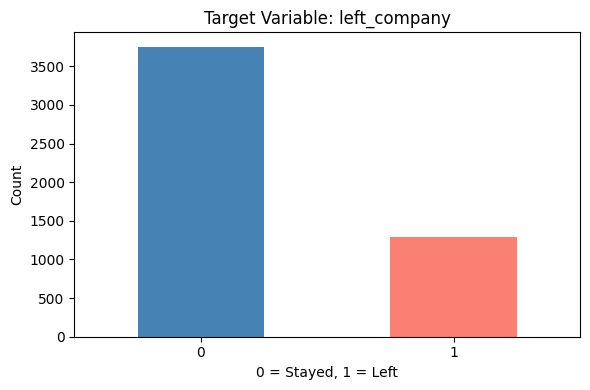

In [18]:
# Visualize target variable balance
plt.figure(figsize=(6, 4))
df["left_company"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Target Variable: left_company")
plt.xlabel("0 = Stayed, 1 = Left")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

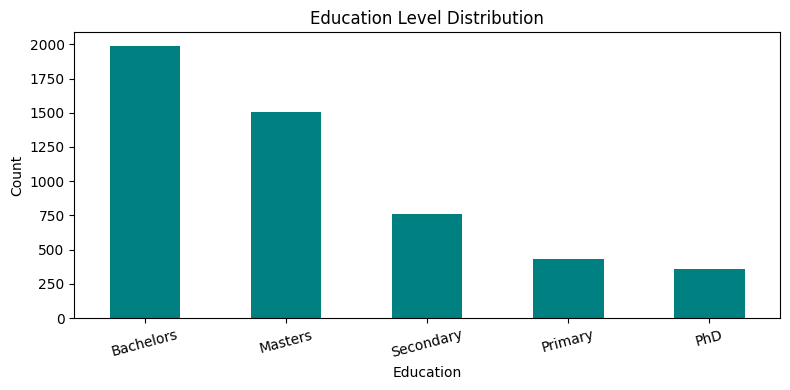

In [19]:
# Education distribution visualized
plt.figure(figsize=(8, 4))
df["education"].value_counts().plot(kind="bar", color="teal")
plt.title("Education Level Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

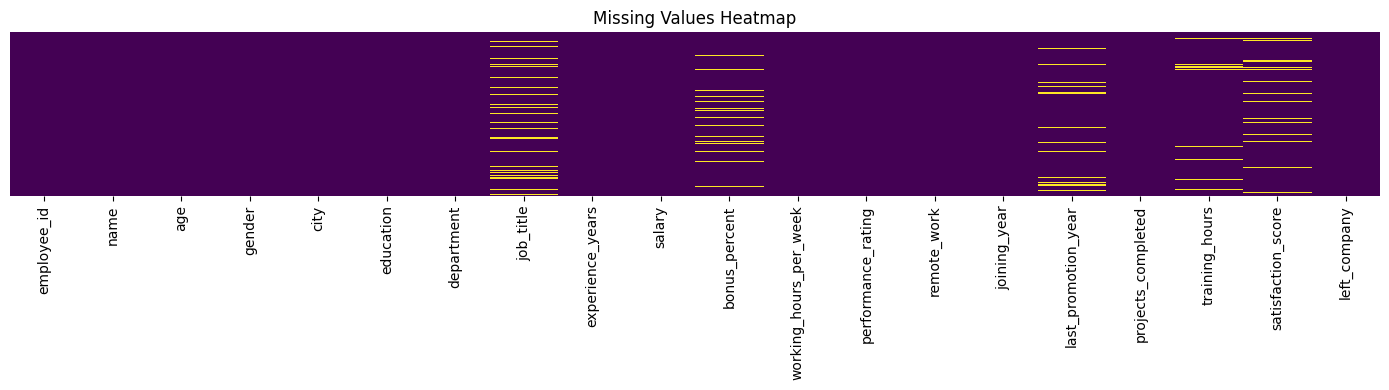

In [20]:
# Heatmap of missing values
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

---
## 🧹 Step 3 — Data Cleaning

We fix the dataset column by column, just like we did in the flight and playstore datasets

In [21]:
df_clean = df.copy()

### 3.1 — Remove Duplicates

In [22]:
# Before
print("Before:", df_clean.shape)

df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

# After
print("After:", df_clean.shape)

Before: (5040, 20)
After: (5003, 20)


In [23]:
df.head()

,employee_id,name,age,gender,city,education,department,job_title,experience_years,salary,bonus_percent,working_hours_per_week,performance_rating,remote_work,joining_year,last_promotion_year,projects_completed,training_hours,satisfaction_score,left_company
0,EMP4351,Edward Garcia,54,Male,Karachi,Masters,HR,Doctor,18,106419,5.0,38,Poor,No,2011,NaN,49,40.0,5.9,0
1,EMP3306,Diana Bradford,25,Male,Multan,Bachelors,Marketing,Teacher,20,51889,0.0,44,Average,Yes,2011,2013.0,22,193.0,2.9,0
2,EMP1737,Zachary Poole,51,Female,Quetta,Bachelors,Finance,Teacher,10,56508,25.0,39,Excellent,Yes,2015,2023.0,41,153.0,9.8,0
3,EMP3051,Alyssa Thompson,46,Male,Multan,Secondary,HR,NaN,27,27058,5.0,51,Good,No,2020,NaN,17,NaN,3.9,1
4,EMP3312,Stephanie Gibson,37,m,Quetta,Masters,Sales,NaN,10,82849,10.0,30,Good,No,2006,2023.0,29,160.0,7.7,0


In [24]:
df_clean['salary'].unique()

<ArrowStringArray>
['106419',  '51889',  '56508',  '27058',  '82849', '100538',  '78144',
  '76192',  '60650',  '36361',
 ...
  '86456',  '72989',  '48937',  '48094', '103326',  '64065',  '66256',
  '66715',  '62726',  '83402']
Length: 4842, dtype: str

In [25]:
### 3.2 — Fix `salary` Column (Remove 'PKR' prefix, convert to int)

df_clean[df_clean["salary"].str.startswith("PKR")].head()

,employee_id,name,age,gender,city,education,department,job_title,experience_years,salary,bonus_percent,working_hours_per_week,performance_rating,remote_work,joining_year,last_promotion_year,projects_completed,training_hours,satisfaction_score,left_company
68,EMP0752,Kathryn Williams,36,Female,Lahore,PhD,Finance,Accountant,13,PKR124337,5.0,59,Excellent,Yes,2023,2017.0,33,34.0,1.5,0
73,EMP1483,Margaret Andersen,39,Male,Peshawar,Bachelors,HR,Teacher,28,PKR64588,20.0,32,Good,Yes,2011,2020.0,37,NaN,8.3,1
111,EMP4823,David Griffin,40,Female,Peshawar,Bachelors,Finance,Designer,20,PKR66822,25.0,41,Good,No,2018,2017.0,19,70.0,7.3,1
303,EMP3835,Michael Liu,38,Female,Islamabad,Bachelors,Sales,Teacher,7,PKR55665,15.0,51,Average,Yes,2018,2019.0,23,51.0,6.7,0
406,EMP4363,Curtis Williams,53,Male,Lahore,Masters,IT,Manager,9,PKR92719,5.0,20,Good,No,2016,2019.0,42,74.0,7.3,1


In [ ]:
# Remove 'PKR' prefix and convert to numeric
df_clean["salary"] = df_clean["salary"].str.replace("PKR", "", regex=False)
df_clean["salary"] = pd.to_numeric(df_clean["salary"], errors="coerce")  # bad rows become NaN

df_clean["salary"].dtype

In [28]:
# Check salary range — are there outliers now?a
df_clean["salary"].describe()

count    4.923000e+03
mean     8.082818e+04
std      3.755097e+05
min     -9.990000e+02
25%      4.441650e+04
50%      6.361500e+04
75%      8.660900e+04
max      9.999999e+06
Name: salary, dtype: float64

In [29]:
# Find unrealistic salary values (0 or negative or way too high)
df_clean[ (df_clean["salary"] <= 0) | (df_clean["salary"] > 500000)]

,employee_id,name,age,gender,city,education,department,job_title,experience_years,salary,bonus_percent,working_hours_per_week,performance_rating,remote_work,joining_year,last_promotion_year,projects_completed,training_hours,satisfaction_score,left_company
28,EMP3168,Casey Hill,56,Male,Quetta,Secondary,HR,Accountant,2,-999.0,10.0,23,Average,No,2007,2010.0,9,65.0,4.6,0
362,EMP3378,Nicole Lee,54,Female,Islamabad,Secondary,IT,Data Analyst,32,-999.0,5.0,25,Excellent,No,2013,2021.0,40,5.0,1.4,1
656,EMP3122,Kathleen Thomas,48,Male,islamabad,Bachelors,IT,Manager,19,-999.0,NaN,23,Average,No,2019,2013.0,36,106.0,4.4,0
713,EMP4476,Debbie Bowman,33,Male,Islamabad,Bachelors,IT,Designer,9,-999.0,10.0,51,Good,No,2008,2010.0,32,137.0,7.9,1
880,EMP2438,Adam Harrison,59,Male,Quetta,Bachelors,Sales,Software Engineer,23,0.0,NaN,53,Excellent,No,2018,2017.0,19,136.0,4.8,0
924,EMP2813,Emily Hall,53,Female,Peshawar,Masters,HR,Teacher,21,0.0,10.0,55,Average,No,2018,2018.0,13,163.0,10.0,0
1314,EMP3858,Brian Nixon,34,Male,Quetta,Bachelors,Marketing,Designer,20,9999999.0,10.0,53,Average,No,2017,2018.0,29,60.0,9.4,0
1385,EMP2464,Paul Campbell,46,Female,Quetta,Bachelors,HR,Sales Executive,28,-999.0,5.0,27,Good,No,2012,2020.0,37,114.0,8.7,0
1506,EMP1470,Robert Mann,54,Female,Islamabad,Masters,IT,Teacher,4,9999999.0,15.0,21,Average,Yes,2010,2019.0,22,178.0,6.6,1
1565,EMP4869,Kimberly Howell,36,Male,Peshawar,Bachelors,Operations,Manager,34,0.0,15.0,27,Average,No,2019,2012.0,44,28.0,8.7,1


In [30]:
# Replace outlier salaries with NaN — we will fill them with median later
df_clean.loc[ (df_clean["salary"] <= 0) | (df_clean["salary"] > 500000), "salary"] = np.nan

# Fill NaN salaries with median
median_salary = df_clean["salary"].median()
df_clean["salary"].fillna(median_salary, inplace=True)

print("Median salary used:", median_salary)
df_clean["salary"].describe()

Median salary used: 63696.0


count      4894.000000
mean      67006.156518
std       29398.278846
min       15439.000000
25%       44939.750000
50%       63696.000000
75%       86611.000000
max      181895.000000
Name: salary, dtype: float64

### 3.3 — Fix `joining_year` Column (Remove 'Year-' prefix)

In [31]:
df_clean.head(5)

,employee_id,name,age,gender,city,education,department,job_title,experience_years,salary,bonus_percent,working_hours_per_week,performance_rating,remote_work,joining_year,last_promotion_year,projects_completed,training_hours,satisfaction_score,left_company
0,EMP4351,Edward Garcia,54,Male,Karachi,Masters,HR,Doctor,18,106419.0,5.0,38,Poor,No,2011,NaN,49,40.0,5.9,0
1,EMP3306,Diana Bradford,25,Male,Multan,Bachelors,Marketing,Teacher,20,51889.0,0.0,44,Average,Yes,2011,2013.0,22,193.0,2.9,0
2,EMP1737,Zachary Poole,51,Female,Quetta,Bachelors,Finance,Teacher,10,56508.0,25.0,39,Excellent,Yes,2015,2023.0,41,153.0,9.8,0
3,EMP3051,Alyssa Thompson,46,Male,Multan,Secondary,HR,NaN,27,27058.0,5.0,51,Good,No,2020,NaN,17,NaN,3.9,1
4,EMP3312,Stephanie Gibson,37,m,Quetta,Masters,Sales,NaN,10,82849.0,10.0,30,Good,No,2006,2023.0,29,160.0,7.7,0


In [ ]:
df_clean["joining_year"].unique()
# container year-210 etc remove it 

<ArrowStringArray>
[     '2011',      '2015',      '2020',      '2006',      '2012',      '2014',
      '2010',      '2018',      '2016',      '2008',      '2013', 'Year-2012',
      '2021',      '2007',      '2005',      '2019',      '2009',      '2017',
      '2022',      '2023', 'Year-2010', 'Year-2005', 'Year-2009', 'Year-2017',
 'Year-2011', 'Year-2022', 'Year-2013', 'Year-2020', 'Year-2006', 'Year-2023',
 'Year-2014', 'Year-2019', 'Year-2008', 'Year-2018', 'Year-2016', 'Year-2021',
 'Year-2015']
Length: 37, dtype: str

In [33]:
df_clean[ df_clean["joining_year"].str.startswith("Year-")].head()

,employee_id,name,age,gender,city,education,department,job_title,experience_years,salary,bonus_percent,working_hours_per_week,performance_rating,remote_work,joining_year,last_promotion_year,projects_completed,training_hours,satisfaction_score,left_company
22,EMP1667,Heather Delgado,54,Male,Islamabad,Secondary,Sales,Designer,0,33239.0,5.0,64,Good,No,Year-2012,2010.0,19,20.0,8.8,0
229,EMP4128,Mitchell Cunningham,41,Female,Lahore,PhD,IT,Sales Executive,14,99019.0,5.0,50,Good,Yes,Year-2010,NaN,25,111.0,NaN,1
516,EMP3327,Teresa Hurst,46,Female,Multan,Masters,Finance,Data Analyst,7,114498.0,10.0,44,Good,No,Year-2005,NaN,32,103.0,1.6,0
607,EMP1933,Thomas Henry,27,Female,Islamabad,Bachelors,Operations,Manager,31,63611.0,0.0,53,Average,Yes,Year-2009,2011.0,22,58.0,NaN,0
619,EMP1752,Steve Martinez,57,Male,Islamabad,Secondary,Marketing,Teacher,19,40910.0,10.0,57,Good,No,Year-2017,2017.0,2,134.0,1.9,1


In [34]:
# Remove 'Year-' prefix and convert to int
df_clean["joining_year"] = df_clean["joining_year"].str.replace("Year-", "", regex=False)
df_clean["joining_year"] = pd.to_numeric(df_clean["joining_year"], errors="coerce").astype("Int16")

df_clean["joining_year"].dtype

Int16Dtype()

In [35]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5003 entries, 0 to 5002
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             5003 non-null   str    
 1   name                    5003 non-null   str    
 2   age                     5003 non-null   int64  
 3   gender                  5003 non-null   str    
 4   city                    5003 non-null   str    
 5   education               5003 non-null   str    
 6   department              5003 non-null   str    
 7   job_title               4077 non-null   str    
 8   experience_years        5003 non-null   int64  
 9   salary                  4894 non-null   float64
 10  bonus_percent           4603 non-null   float64
 11  working_hours_per_week  5003 non-null   int64  
 12  performance_rating      5003 non-null   str    
 13  remote_work             5003 non-null   str    
 14  joining_year            5003 non-null   Int16  
 15

### 3.4 — Fix `gender` Column (Standardize inconsistent strings)

In [36]:
# See all unique messy values
df_clean["gender"].unique()

<ArrowStringArray>
['Male', 'Female', 'm', 'male', 'M', 'MALE', 'FEMALE', 'female', 'F', 'f']
Length: 10, dtype: str

In [39]:
# Standardize: lowercase everything first, then map to proper values
df_clean["gender"] = df_clean["gender"].str.strip().str.lower()

# Map all variations to one standard form
gender_map = {
    "male":   "Male",
    "m":      "Male",
    "female": "Female",
    "f":      "Female"
}

df_clean["gender"] = df_clean["gender"].map(gender_map)

df_clean["gender"] = df_clean["gender"].astype("category")

# Verify — should only have Male / Female now
df_clean["gender"].value_counts()

gender
Male      3013
Female    1990
Name: count, dtype: int64

In [40]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5003 entries, 0 to 5002
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   employee_id             5003 non-null   str     
 1   name                    5003 non-null   str     
 2   age                     5003 non-null   int64   
 3   gender                  5003 non-null   category
 4   city                    5003 non-null   str     
 5   education               5003 non-null   str     
 6   department              5003 non-null   str     
 7   job_title               4077 non-null   str     
 8   experience_years        5003 non-null   int64   
 9   salary                  4894 non-null   float64 
 10  bonus_percent           4603 non-null   float64 
 11  working_hours_per_week  5003 non-null   int64   
 12  performance_rating      5003 non-null   str     
 13  remote_work             5003 non-null   str     
 14  joining_year            5003 non-nu

### 3.5 — Fix `city` Column (Standardize inconsistent strings)

In [41]:
# See messy unique values
df_clean["city"].unique()

<ArrowStringArray>
[   'Karachi',     'Multan',     'Quetta',   'Peshawar',  'Islamabad',
     'Lahore',    ' Multan',    'karachi', 'islamabad ',     'LAHORE']
Length: 10, dtype: str

In [42]:
# Strip whitespace and title case everything
df_clean["city"] = df_clean["city"].str.strip().str.title()

# Verify
df_clean["city"].value_counts()

city
Lahore       870
Multan       858
Karachi      854
Peshawar     832
Islamabad    822
Quetta       767
Name: count, dtype: int64

### 3.6 — Fix `age` Column (Remove outliers)

In [ ]:
df_clean["age"].unique()
# see there is 0 and -5 age 

array([ 54,  25,  51,  46,  37,  50,  43,  55,  26,  39,  57,  30,  33,
        53,  32,  49,  40,  47,  31,  23,  56,  34,  58,  42,  28,  22,
        45,  35,  41,  48,  27,  59,  52,  36,  38,  29,  24,  44, 150,
        -5,   0])

In [49]:
# Replace bad ages with NaN and fill with median
df_clean.loc[ (df_clean["age"] < 18) | (df_clean["age"] > 70), "age" ] = np.nan

median_age = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(median_age)
df_clean["age"] = df_clean["age"].astype("int64")

print("Median age used:", median_age)
df_clean["age"].describe()

Median age used: 40.0


count    5003.000000
mean       40.400160
std        10.821614
min        22.000000
25%        31.000000
50%        40.000000
75%        50.000000
max        59.000000
Name: age, dtype: float64

### 3.7 — Handle Missing Values in Other Columns

In [50]:
# Check which cols still have NaN
df_clean.isnull().sum()

employee_id                 0
name                        0
age                         0
gender                      0
city                        0
education                   0
department                  0
job_title                 926
experience_years            0
salary                    109
bonus_percent             400
working_hours_per_week      0
performance_rating          0
remote_work                 0
joining_year                0
last_promotion_year       401
projects_completed          0
training_hours            401
satisfaction_score        400
left_company                0
dtype: int64

In [51]:
df_clean["job_title"].unique()

<ArrowStringArray>
[           'Doctor',           'Teacher',                 nan,
           'Manager', 'Software Engineer',   'Sales Executive',
          'Designer',        'Accountant',      'Data Analyst']
Length: 9, dtype: str

In [54]:
# job_title is categorical — fill missing with 'Unknown'
df_clean["job_title"] = df_clean["job_title"].fillna("Unknown")

# bonus_percent is numerical — fill with median
df_clean["bonus_percent"] = df_clean["bonus_percent"].fillna(df_clean["bonus_percent"].median())

# training_hours is numerical — fill with median
df_clean["training_hours"] = df_clean["training_hours"].fillna(df_clean["training_hours"].median())

# satisfaction_score is numerical — fill with mean
df_clean["satisfaction_score"] = df_clean["satisfaction_score"].fillna(df_clean["satisfaction_score"].mean())

# last_promotion_year — fill with joining_year (assume no promotion yet)
df_clean["last_promotion_year"] = df_clean["last_promotion_year"].fillna(df_clean["joining_year"])

In [55]:
# Verify — should be 0 nulls now
df_clean.isnull().sum()

employee_id                 0
name                        0
age                         0
gender                      0
city                        0
education                   0
department                  0
job_title                   0
experience_years            0
salary                    109
bonus_percent               0
working_hours_per_week      0
performance_rating          0
remote_work                 0
joining_year                0
last_promotion_year         0
projects_completed          0
training_hours              0
satisfaction_score          0
left_company                0
dtype: int64

In [56]:
df_clean["salary"] = df_clean["salary"].fillna(df_clean["salary"].mean())

In [57]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5003 entries, 0 to 5002
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   employee_id             5003 non-null   str     
 1   name                    5003 non-null   str     
 2   age                     5003 non-null   int64   
 3   gender                  5003 non-null   category
 4   city                    5003 non-null   str     
 5   education               5003 non-null   str     
 6   department              5003 non-null   str     
 7   job_title               5003 non-null   str     
 8   experience_years        5003 non-null   int64   
 9   salary                  5003 non-null   float64 
 10  bonus_percent           5003 non-null   float64 
 11  working_hours_per_week  5003 non-null   int64   
 12  performance_rating      5003 non-null   str     
 13  remote_work             5003 non-null   str     
 14  joining_year            5003 non-nu

---
## ⚙️ Step 4 — Feature Engineering

Create new meaningful features from existing columns

In [58]:
# 4.1 — years_since_promotion
# How long has it been since the employee was promoted?
# High value = employee might be unhappy

current_year = 2024
df_clean["years_since_promotion"] = current_year - df_clean["last_promotion_year"]

df_clean[["last_promotion_year", "years_since_promotion"]].head()

,last_promotion_year,years_since_promotion
0,2011.0,13.0
1,2013.0,11.0
2,2023.0,1.0
3,2020.0,4.0
4,2023.0,1.0


In [59]:
# 4.2 — tenure (how many years employee has been working here)

df_clean["tenure"] = current_year - df_clean["joining_year"]

df_clean[["joining_year", "tenure"]].head()

,joining_year,tenure
0,2011,13
1,2011,13
2,2015,9
3,2020,4
4,2006,18


In [60]:
# 4.3 — salary_per_project
# How much is the employee earning per project completed?
# Avoid division by zero

df_clean["salary_per_project"] = df_clean.apply(
    lambda row: round(row["salary"] / row["projects_completed"]) if row["projects_completed"] > 0 else 0,
    axis=1
)

df_clean[["salary", "projects_completed", "salary_per_project"]].head()

,salary,projects_completed,salary_per_project
0,106419.0,49,2172
1,51889.0,22,2359
2,56508.0,41,1378
3,27058.0,17,1592
4,82849.0,29,2857


In [61]:
# 4.4 — total_compensation
# salary + bonus amount

df_clean["total_compensation"] = df_clean["salary"] + (df_clean["salary"] * df_clean["bonus_percent"] / 100)
df_clean["total_compensation"] = df_clean["total_compensation"].round(2)

df_clean[["salary", "bonus_percent", "total_compensation"]].head()

,salary,bonus_percent,total_compensation
0,106419.0,5.0,111739.95
1,51889.0,0.0,51889.00
2,56508.0,25.0,70635.00
3,27058.0,5.0,28410.90
4,82849.0,10.0,91133.90


In [62]:
# 4.5 — age group (bin age into categories)

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[18, 25, 35, 45, 70],
    labels=["Junior", "Mid", "Senior", "Veteran"]
)

df_clean["age_group"].value_counts()

age_group
Veteran    1793
Senior     1378
Mid        1322
Junior      510
Name: count, dtype: int64

In [63]:
# 4.6 — drop cols we no longer need
# employee_id and name are identifiers — not useful for ML
# joining_year and last_promotion_year are now captured in tenure and years_since_promotion

df_clean.drop(["employee_id", "name", "joining_year", "last_promotion_year"], axis=1, inplace=True)

df_clean.head()

,age,gender,city,education,department,job_title,experience_years,salary,bonus_percent,working_hours_per_week,...,remote_work,projects_completed,training_hours,satisfaction_score,left_company,years_since_promotion,tenure,salary_per_project,total_compensation,age_group
0,54,Male,Karachi,Masters,HR,Doctor,18,106419.0,5.0,38,...,No,49,40.0,5.9,0,13.0,13,2172,111739.95,Veteran
1,25,Male,Multan,Bachelors,Marketing,Teacher,20,51889.0,0.0,44,...,Yes,22,193.0,2.9,0,11.0,13,2359,51889.00,Junior
2,51,Female,Quetta,Bachelors,Finance,Teacher,10,56508.0,25.0,39,...,Yes,41,153.0,9.8,0,1.0,9,1378,70635.00,Veteran
3,46,Male,Multan,Secondary,HR,Unknown,27,27058.0,5.0,51,...,No,17,99.0,3.9,1,4.0,4,1592,28410.90,Veteran
4,37,Male,Quetta,Masters,Sales,Unknown,10,82849.0,10.0,30,...,No,29,160.0,7.7,0,1.0,18,2857,91133.90,Senior


---
## 🔢 Step 5 — Encoding Categorical Columns

ML models only understand numbers — time to encode all categorical cols

| Column | Encoding Method | Reason |
|--------|----------------|--------|
| gender | Label Encoding | Only 2 values — binary |
| remote_work | Label Encoding | Only Yes/No — binary |
| city | One Hot Encoding | Nominal — no order |
| department | One Hot Encoding | Nominal — no order |
| education | Ordinal Encoding | Has natural order |
| performance_rating | Ordinal Encoding | Has natural order |
| age_group | Ordinal Encoding | Has natural order |
| job_title | Target Guided Ordinal | Many categories, no clear order |


In [64]:
# See all current columns and their types
df_clean.dtypes

age                          int64
gender                    category
city                           str
education                      str
department                     str
job_title                      str
experience_years             int64
salary                     float64
bonus_percent              float64
working_hours_per_week       int64
performance_rating             str
remote_work                    str
projects_completed           int64
training_hours             float64
satisfaction_score         float64
left_company                 int64
years_since_promotion      float64
tenure                       Int16
salary_per_project           int64
total_compensation         float64
age_group                 category
dtype: object

### 5.1 — Label Encoding (gender, remote_work)

In [65]:
le = LabelEncoder()

# gender: Male / Female
df_clean["gender"] = le.fit_transform(df_clean["gender"])
print("gender classes:", le.classes_)  # see what 0 and 1 map to

# remote_work: Yes / No
df_clean["remote_work"] = le.fit_transform(df_clean["remote_work"])
print("remote_work classes:", le.classes_)

gender classes: ['Female' 'Male']
remote_work classes: ['No' 'Yes']


In [66]:
df_clean[["gender", "remote_work"]].head()

,gender,remote_work
0,1,0
1,1,1
2,0,1
3,1,0
4,1,0


### 5.2 — Ordinal Encoding (education, performance_rating, age_group)

In [67]:
# Education has a natural order: Primary < Secondary < Bachelors < Masters < PhD
edu_order = [["Primary", "Secondary", "Bachelors", "Masters", "PhD"]]

oe_edu = OrdinalEncoder(categories=edu_order)
df_clean["education"] = oe_edu.fit_transform(df_clean[["education"]])

print("Education encoded:", oe_edu.categories_)
df_clean[["education"]].head()

Education encoded: [array(['Primary', 'Secondary', 'Bachelors', 'Masters', 'PhD'],
      dtype=object)]


,education
0,3.0
1,2.0
2,2.0
3,1.0
4,3.0


In [68]:
# Performance rating has a natural order: Poor < Average < Good < Excellent
perf_order = [["Poor", "Average", "Good", "Excellent"]]

oe_perf = OrdinalEncoder(categories=perf_order)
df_clean["performance_rating"] = oe_perf.fit_transform(df_clean[["performance_rating"]])

print("Performance encoded:", oe_perf.categories_)
df_clean[["performance_rating"]].head()

Performance encoded: [array(['Poor', 'Average', 'Good', 'Excellent'], dtype=object)]


,performance_rating
0,0.0
1,1.0
2,3.0
3,2.0
4,2.0


In [69]:
# age_group has a natural order: Junior < Mid < Senior < Veteran
age_order = [["Junior", "Mid", "Senior", "Veteran"]]

oe_age = OrdinalEncoder(categories=age_order)
df_clean["age_group"] = oe_age.fit_transform(df_clean[["age_group"]])

print("Age group encoded:", oe_age.categories_)
df_clean[["age_group"]].head()

Age group encoded: [array(['Junior', 'Mid', 'Senior', 'Veteran'], dtype=object)]


,age_group
0,3.0
1,0.0
2,3.0
3,3.0
4,2.0


### 5.3 — One Hot Encoding (city, department)

In [70]:
# One hot encoding using pandas get_dummies
# drop_first=True removes one col to avoid dummy variable trap

df_clean = pd.get_dummies(df_clean, columns=["city", "department"], drop_first=True)

# Check new columns
df_clean.columns

Index(['age', 'gender', 'education', 'job_title', 'experience_years', 'salary',
       'bonus_percent', 'working_hours_per_week', 'performance_rating',
       'remote_work', 'projects_completed', 'training_hours',
       'satisfaction_score', 'left_company', 'years_since_promotion', 'tenure',
       'salary_per_project', 'total_compensation', 'age_group', 'city_Karachi',
       'city_Lahore', 'city_Multan', 'city_Peshawar', 'city_Quetta',
       'department_HR', 'department_IT', 'department_Marketing',
       'department_Operations', 'department_Sales'],
      dtype='str')

### 5.4 — Target Guided Ordinal Encoding (job_title)

In [71]:
# job_title has many categories (8+) and no natural order
# So we rank them by their mean salary (target-related feature)

# Step 1: Calculate mean salary per job_title
job_salary_mean = df_clean.groupby("job_title")["salary"].mean().sort_values()
print(job_salary_mean)

job_title
Teacher              65115.301203
Sales Executive      65405.654528
Manager              65825.004238
Unknown              66671.221758
Software Engineer    66933.858032
Accountant           67369.509199
Designer             68351.984202
Doctor               68608.578385
Data Analyst         68960.830598
Name: salary, dtype: float64


In [ ]:
# job_title has many categories (8+) and no natural order
# So we rank them by their mean salary (target-related feature)

# Step 1: Calculate mean salary per job_title
job_salary_mean = df_clean.groupby("job_title")["salary"].mean().sort_values()
print(job_salary_mean)

In [72]:
# Step 2: Assign rank (1 = lowest avg salary, higher = higher avg salary)
job_rank_map = {job: rank+1 for rank, job in enumerate(job_salary_mean.index)}
print(job_rank_map)

{'Teacher': 1, 'Sales Executive': 2, 'Manager': 3, 'Unknown': 4, 'Software Engineer': 5, 'Accountant': 6, 'Designer': 7, 'Doctor': 8, 'Data Analyst': 9}


In [73]:
# Step 3: Replace job_title with its rank
df_clean["job_title"] = df_clean["job_title"].map(job_rank_map)

df_clean[["job_title"]].head(10)

,job_title
0,8
1,1
2,1
3,4
4,4
5,3
6,5
7,2
8,7
9,6


---
## ✅ Step 6 — Final Check — Dataset Ready For ML

In [75]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5003 entries, 0 to 5002
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5003 non-null   int64  
 1   gender                  5003 non-null   int64  
 2   education               5003 non-null   float64
 3   job_title               5003 non-null   int64  
 4   experience_years        5003 non-null   int64  
 5   salary                  5003 non-null   float64
 6   bonus_percent           5003 non-null   float64
 7   working_hours_per_week  5003 non-null   int64  
 8   performance_rating      5003 non-null   float64
 9   remote_work             5003 non-null   int64  
 10  projects_completed      5003 non-null   int64  
 11  training_hours          5003 non-null   float64
 12  satisfaction_score      5003 non-null   float64
 13  left_company            5003 non-null   int64  
 14  years_since_promotion   5003 non-null   float64
 15

In [76]:
df_clean.head()

,age,gender,education,job_title,experience_years,salary,bonus_percent,working_hours_per_week,performance_rating,remote_work,...,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,department_HR,department_IT,department_Marketing,department_Operations,department_Sales
0,54,1,3.0,8,18,106419.0,5.0,38,0.0,0,...,True,False,False,False,False,True,False,False,False,False
1,25,1,2.0,1,20,51889.0,0.0,44,1.0,1,...,False,False,True,False,False,False,False,True,False,False
2,51,0,2.0,1,10,56508.0,25.0,39,3.0,1,...,False,False,False,False,True,False,False,False,False,False
3,46,1,1.0,4,27,27058.0,5.0,51,2.0,0,...,False,False,True,False,False,True,False,False,False,False
4,37,1,3.0,4,10,82849.0,10.0,30,2.0,0,...,False,False,False,False,True,False,False,False,False,True


In [77]:
# Separate features (X) and target (y)
X = df_clean.drop("left_company", axis=1)
y = df_clean["left_company"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (5003, 28)
y shape: (5003,)

Target distribution:
left_company
0    3727
1    1276
Name: count, dtype: int64
